In [11]:
# train_knn.py

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score
import joblib

# 1. Load dataset
data_path = "vibe_dataset_7000.csv"   # change if needed
df = pd.read_csv(data_path)

# 2. Define features and target
target_col = "vibe"
feature_cols = [
    "latitude",
    "longitude",
    "elevation",
    "weather",
    "time_of_day",
    "population",
    "cultural_aspect",
    "language",
]

X = df[feature_cols]
y = df[target_col]

# 3. Separate numeric and categorical features
numeric_features = ["latitude", "longitude", "elevation", "population"]
categorical_features = ["weather", "time_of_day", "cultural_aspect", "language"]

# 4. Preprocessor: scale numeric + one-hot encode categorical
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown="ignore")

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

# 5. Define KNN model
knn = KNeighborsClassifier(
    n_neighbors=5,
    weights="distance",    # gives closer points more importance
    metric="minkowski",    # Euclidean distance by default
)

# 6. Build full pipeline
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("knn", knn),
    ]
)

# 7. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,   # keep class balance
)

# 8. Train the model
model.fit(X_train, y_train)

# 9. Evaluate on test data (optional but useful during training)
y_pred = model.predict(X_test)
print(" KNN Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# 10. Save the trained pipeline as a .pkl file
model_path = "knn_vibe_model.pkl"
joblib.dump(model, model_path)
print(f"\n Trained KNN model saved to: {model_path}")


 KNN Test Accuracy: 0.9730848861283644

Classification Report:

              precision    recall  f1-score   support

   backwater       0.99      1.00      0.99        96
       beach       0.96      0.97      0.96        97
        city       0.96      0.96      0.96        97
     coastal       0.98      0.96      0.97        97
coastal-city       0.95      0.99      0.97        97
    cultural       0.99      0.97      0.98        96
      desert       1.00      1.00      1.00        97
      forest       1.00      1.00      1.00        97
    heritage       0.92      0.97      0.94        96
   hill-town       0.98      0.97      0.97        96
    mountain       0.99      0.98      0.98        97
       rural       0.95      0.94      0.94        96
   spiritual       0.99      1.00      0.99        97
 temple-town       0.99      0.99      0.99        96
       urban       0.96      0.91      0.93        97

    accuracy                           0.97      1449
   macro avg    

In [12]:
# test_knn.py

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import joblib

# -----------------------------
# 1. Load the trained model
# -----------------------------
model_path = "knn_vibe_model.pkl"   # make sure this was trained on the SAME dataset version
model = joblib.load(model_path)
print(f" Loaded trained model from: {model_path}")

# -----------------------------
# 2. Load the dataset
#    IMPORTANT: use the SAME file you used in train_knn.py
# -----------------------------
data_path = "vibe_dataset_7000.csv"  # or vibe_dataset_7000_balanced.csv or your chosen file
df = pd.read_csv(data_path)

target_col = "vibe"
feature_cols = [
    "latitude",
    "longitude",
    "elevation",
    "weather",
    "time_of_day",
    "population",
    "cultural_aspect",
    "language",
]

X = df[feature_cols]
y = df[target_col]

# -----------------------------
# 3. Recreate the SAME train-test split as in training
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

# -----------------------------
# 4. Example: Predict vibe for a NEW location

# Example: a beach-like location (you can tweak values)
new_location = pd.DataFrame(
    [{
        "latitude": 27.0392,          # Goa-ish
        "longitude": 88.2639,
        "elevation": 2100,              # near sea level
        "weather": "cold",           # typical coastal
        "time_of_day": "afternoon",
        "population": 170000,         # medium tourist town
        "cultural_aspect": "tibetan",
        "language": "hindi",
    }]
)

print("\n Features for new location:")
print(new_location)

predicted_vibe = model.predict(new_location)[0]
print("\n Predicted vibe for new location:", predicted_vibe)


 Loaded trained model from: knn_vibe_model.pkl

 Features for new location:
   latitude  longitude  elevation weather time_of_day  population  \
0   27.0392    88.2639       2100    cold   afternoon      170000   

  cultural_aspect language  
0         tibetan    hindi  

 Predicted vibe for new location: mountain


In [13]:
# train_cnn.py

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
import joblib

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# -----------------------------
# 1. Load dataset
# -----------------------------
data_path = "vibe_dataset_7000.csv"
df = pd.read_csv(data_path)

target_col = "vibe"
feature_cols = [
    "latitude",
    "longitude",
    "elevation",
    "weather",
    "time_of_day",
    "population",
    "cultural_aspect",
    "language",
]

X = df[feature_cols]
y = df[target_col]

# -----------------------------
# 2. Encode target (vibe)
# -----------------------------
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
num_classes = len(label_encoder.classes_)

print("Classes:", label_encoder.classes_)
print("Number of classes:", num_classes)

# -----------------------------
# 3. Train-test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded,
)

# -----------------------------
# 4. Preprocessing for features
# -----------------------------
numeric_features = ["latitude", "longitude", "elevation", "population"]
categorical_features = ["weather", "time_of_day", "cultural_aspect", "language"]

numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown="ignore")

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

# Fit preprocessor on TRAIN only
preprocessor.fit(X_train)

# Transform train & test
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Convert sparse → dense if needed
if hasattr(X_train_processed, "toarray"):
    X_train_processed = X_train_processed.toarray()
    X_test_processed = X_test_processed.toarray()

n_features = X_train_processed.shape[1]
print("Number of features after preprocessing:", n_features)

# -----------------------------
# 5. Reshape for CNN input
#    (samples, timesteps, channels)
# -----------------------------
X_train_cnn = X_train_processed.reshape(-1, n_features, 1)
X_test_cnn = X_test_processed.reshape(-1, n_features, 1)

# -----------------------------
# 6. Build CNN model
# -----------------------------
def build_cnn(input_shape, num_classes):
    model = models.Sequential([
        layers.Conv1D(64, kernel_size=3, activation="relu", padding="same", input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),

        layers.Conv1D(128, kernel_size=3, activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),

        layers.Conv1D(128, kernel_size=3, activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.GlobalAveragePooling1D(),

        layers.Dense(128, activation="relu"),
        layers.Dropout(0.4),
        layers.Dense(num_classes, activation="softmax"),
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

input_shape = (n_features, 1)
model = build_cnn(input_shape, num_classes)
model.summary()

# -----------------------------
# 7. Callbacks (EarlyStopping + best model checkpoint)
# -----------------------------
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    verbose=1,
)

checkpoint_path = "cnn_best_weights.keras"
checkpoint = ModelCheckpoint(
    checkpoint_path,
    monitor="val_loss",
    save_best_only=True,
    save_weights_only=False,
    verbose=1,
)

# -----------------------------
# 8. Train CNN
# -----------------------------
history = model.fit(
    X_train_cnn,
    y_train,
    validation_split=0.1,
    epochs=100,          # EarlyStopping will stop earlier if no improvement
    batch_size=32,
    callbacks=[early_stop, checkpoint],
    verbose=1,
)

# If checkpoint saved a better model, load it
try:
    best_model = tf.keras.models.load_model(checkpoint_path)
    print("\nLoaded best model from checkpoint.")
except Exception as e:
    print("\nCould not load checkpoint, using last-epoch model.")
    best_model = model

# -----------------------------
# 9. Evaluate
# -----------------------------
test_loss, test_acc = best_model.evaluate(X_test_cnn, y_test, verbose=0)
print(f"\n✅ CNN Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# -----------------------------
# 10. Save model + preprocessors
# -----------------------------

# Save Keras CNN model
best_model.save("cnn_vibe_model.keras")

# Save preprocessor and label encoder
joblib.dump(preprocessor, "cnn_preprocessor.pkl")
joblib.dump(label_encoder, "cnn_label_encoder.pkl")

# Also save as .pkl (full model object)
joblib.dump({"model": best_model}, "cnn_vibe_model.pkl")

print("\n✅ Saved:")
print(" - cnn_vibe_model.keras")
print(" - cnn_vibe_model.pkl")
print(" - cnn_preprocessor.pkl")
print(" - cnn_label_encoder.pkl")


Classes: ['backwater' 'beach' 'city' 'coastal' 'coastal-city' 'cultural' 'desert'
 'forest' 'heritage' 'hill-town' 'mountain' 'rural' 'spiritual'
 'temple-town' 'urban']
Number of classes: 15
Number of features after preprocessing: 58


C:\Users\labanya\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_6 (Conv1D)               │ (None, 58, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 58, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 29, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 29, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 29, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 14, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_8 (Conv1D)               │ (None, 14, 128)        │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 14, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 15)             │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,967 (367.06 KB)

 Trainable params: 93,327 (364.56 KB)

 Non-trainable params: 640 (2.50 KB)

Epoch 1/100
160/163 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5722 - loss: 1.6092
Epoch 1: val_loss improved from inf to 7.42130, saving model to cnn_best_weights.keras
163/163 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5766 - loss: 1.5939 - val_accuracy: 0.0603 - val_loss: 7.4213
Epoch 2/100
161/163 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9111 - loss: 0.3153
Epoch 2: val_loss did not improve from 7.42130
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9112 - loss: 0.3147 - val_accuracy: 0.0603 - val_loss: 11.4237
Epoch 3/100
159/163 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9466 - loss: 0.1890
Epoch 3: val_loss improved from 7.42130 to 3.57763, saving model to cnn_best_weights.keras
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9465 - loss: 0.1891 - val_accuracy: 0.2052 - val_loss: 3.5776
Epoch 4/100
161/163 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9510 - loss: 0.1616
Epoch 4: val_loss improved from 3.57763 to 0.18830, saving model to cnn_bes

In [15]:
#Decision Tree

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
import joblib

# Load dataset
df = pd.read_csv("vibe_dataset_7000.csv")

X = df.drop("vibe", axis=1)
y = df["vibe"]

numeric_features = ["latitude", "longitude", "elevation", "population"]
categorical_features = ["weather", "time_of_day", "cultural_aspect", "language"]

preprocessor = ColumnTransformer(
    [
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

dt = DecisionTreeClassifier(
    criterion="gini",
    max_depth=20,
    random_state=42
)

model = Pipeline([
    ("preprocessor", preprocessor),
    ("dt", dt)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

joblib.dump(model, "decision_tree_vibe_model.pkl")


Decision Tree Accuracy: 0.9930986887508627
              precision    recall  f1-score   support

   backwater       1.00      1.00      1.00        96
       beach       0.98      1.00      0.99        97
        city       0.99      0.97      0.98        97
     coastal       1.00      1.00      1.00        97
coastal-city       1.00      0.99      0.99        97
    cultural       1.00      1.00      1.00        96
      desert       0.99      1.00      0.99        97
      forest       1.00      1.00      1.00        97
    heritage       0.99      0.99      0.99        96
   hill-town       0.98      1.00      0.99        96
    mountain       1.00      1.00      1.00        97
       rural       1.00      0.98      0.99        96
   spiritual       1.00      1.00      1.00        97
 temple-town       1.00      0.99      0.99        96
       urban       0.97      0.98      0.97        97

    accuracy                           0.99      1449
   macro avg       0.99      0.99    

['decision_tree_vibe_model.pkl']

In [18]:
#Random Forest

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import joblib

df = pd.read_csv("vibe_dataset_7000.csv")

X = df.drop("vibe", axis=1)
y = df["vibe"]

numeric_features = ["latitude", "longitude", "elevation", "population"]
categorical_features = ["weather", "time_of_day", "cultural_aspect", "language"]

preprocessor = ColumnTransformer(
    [
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=25,
    random_state=42,
    n_jobs=-1
)

model = Pipeline([
    ("preprocessor", preprocessor),
    ("rf", rf)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

joblib.dump(model, "random_forest_vibe_model.pkl")


Random Forest Accuracy: 0.9979296066252588
              precision    recall  f1-score   support

   backwater       1.00      1.00      1.00        96
       beach       0.99      1.00      0.99        97
        city       1.00      0.99      0.99        97
     coastal       1.00      1.00      1.00        97
coastal-city       1.00      0.99      0.99        97
    cultural       1.00      1.00      1.00        96
      desert       1.00      1.00      1.00        97
      forest       1.00      1.00      1.00        97
    heritage       0.99      1.00      0.99        96
   hill-town       1.00      0.99      0.99        96
    mountain       1.00      1.00      1.00        97
       rural       1.00      1.00      1.00        96
   spiritual       1.00      1.00      1.00        97
 temple-town       1.00      1.00      1.00        96
       urban       0.99      1.00      0.99        97

    accuracy                           1.00      1449
   macro avg       1.00      1.00    

['random_forest_vibe_model.pkl']

In [19]:
#Gradient Boosting

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report
import joblib

df = pd.read_csv("vibe_dataset_7000.csv")

X = df.drop("vibe", axis=1)
y = df["vibe"]

numeric_features = ["latitude", "longitude", "elevation", "population"]
categorical_features = ["weather", "time_of_day", "cultural_aspect", "language"]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
])

model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(
        n_estimators=150,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    ))
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

joblib.dump(model, "gradient_boosting_vibe_model.pkl")


Gradient Boosting Accuracy: 0.9951690821256038
              precision    recall  f1-score   support

   backwater       1.00      1.00      1.00        96
       beach       0.99      1.00      0.99        97
        city       1.00      0.97      0.98        97
     coastal       1.00      1.00      1.00        97
coastal-city       1.00      0.99      0.99        97
    cultural       1.00      1.00      1.00        96
      desert       1.00      1.00      1.00        97
      forest       0.99      1.00      0.99        97
    heritage       1.00      1.00      1.00        96
   hill-town       0.99      0.99      0.99        96
    mountain       1.00      0.98      0.99        97
       rural       1.00      1.00      1.00        96
   spiritual       1.00      1.00      1.00        97
 temple-town       1.00      1.00      1.00        96
       urban       0.96      1.00      0.98        97

    accuracy                           1.00      1449
   macro avg       1.00      1.00

['gradient_boosting_vibe_model.pkl']

In [21]:
#XG Boost

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier
import joblib

# 1. Load dataset
df = pd.read_csv("vibe_dataset_7000.csv")

# 2. Features and target
feature_cols = [
    "latitude",
    "longitude",
    "elevation",
    "weather",
    "time_of_day",
    "population",
    "cultural_aspect",
    "language",
]

X = df[feature_cols]
y = df["vibe"]

# 3. Encode target labels (IMPORTANT)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# 4. Numeric & categorical features
numeric_features = ["latitude", "longitude", "elevation", "population"]
categorical_features = ["weather", "time_of_day", "cultural_aspect", "language"]

# 5. Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

# 6. XGBoost Classifier
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    num_class=len(label_encoder.classes_),
    eval_metric="mlogloss",
    random_state=42
)

# 7. Pipeline
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("xgb", xgb),
    ]
)

# 8. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# 9. Train model
model.fit(X_train, y_train)

# 10. Evaluate
y_pred = model.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

# 11. Save model and label encoder
joblib.dump(model, "xgboost_vibe_model.pkl")
joblib.dump(label_encoder, "vibe_label_encoder.pkl")

print("\nXGBoost model and label encoder saved successfully.")


XGBoost Accuracy: 0.9979296066252588

Classification Report:

              precision    recall  f1-score   support

   backwater       1.00      1.00      1.00        96
       beach       0.99      1.00      0.99        97
        city       0.99      0.99      0.99        97
     coastal       1.00      1.00      1.00        97
coastal-city       1.00      0.99      0.99        97
    cultural       1.00      1.00      1.00        96
      desert       1.00      1.00      1.00        97
      forest       1.00      1.00      1.00        97
    heritage       1.00      1.00      1.00        96
   hill-town       1.00      1.00      1.00        96
    mountain       1.00      1.00      1.00        97
       rural       1.00      1.00      1.00        96
   spiritual       1.00      1.00      1.00        97
 temple-town       1.00      1.00      1.00        96
       urban       0.99      0.99      0.99        97

    accuracy                           1.00      1449
   macro avg      

In [23]:
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import tensorflow as tf

# ================= CONFIG =================
dataset_path = "vibe_dataset_7000.csv"

models_info = {
    "Random Forest": "random_forest_vibe_model.pkl",
    "Gradient Boosting": "gradient_boosting_vibe_model.pkl",
    "XGBoost": "xgboost_vibe_model.pkl",
    "Decision Tree": "decision_tree_vibe_model.pkl",
    "KNN": "knn_vibe_model.pkl",
}

cnn_model_path = "cnn_vibe_model.keras"
cnn_preprocessor_path = "cnn_preprocessor.pkl"
label_encoder_path = "cnn_label_encoder.pkl"
# ==========================================

# -------- Load dataset --------
df = pd.read_csv(dataset_path)

feature_cols = [
    "latitude", "longitude", "elevation",
    "weather", "time_of_day",
    "population", "cultural_aspect", "language"
]

X = df[feature_cols]
y_text = df["vibe"]

# -------- Train-test split --------
X_train, X_test, y_train_text, y_test_text = train_test_split(
    X, y_text, test_size=0.2, random_state=42, stratify=y_text
)

# -------- Load label encoder --------
label_encoder = joblib.load(label_encoder_path)
y_test_enc = label_encoder.transform(y_test_text)

rows = []

# ==================================================
# 1️⃣ Evaluate SKLEARN MODELS
# ==================================================
for alg_name, model_path in models_info.items():

    if not os.path.exists(model_path):
        rows.append({
            "Algorithm": alg_name,
            "Accuracy": None,
            "Precision": None,
            "Recall": None,
            "F1-Score": None
        })
        continue

    model = joblib.load(model_path)
    y_pred = model.predict(X_test)

    # 🔥 Fix label mismatch (string → encoded)
    if isinstance(y_pred[0], str):
        y_pred = label_encoder.transform(y_pred)

    rows.append({
        "Algorithm": alg_name,
        "Accuracy": round(accuracy_score(y_test_enc, y_pred), 5),
        "Precision": round(precision_score(y_test_enc, y_pred, average="weighted", zero_division=0), 5),
        "Recall": round(recall_score(y_test_enc, y_pred, average="weighted", zero_division=0), 5),
        "F1-Score": round(f1_score(y_test_enc, y_pred, average="weighted", zero_division=0), 5),
    })

# ==================================================
# 2️⃣ Evaluate CNN MODEL
# ==================================================
if os.path.exists(cnn_model_path) and os.path.exists(cnn_preprocessor_path):

    cnn_model = tf.keras.models.load_model(cnn_model_path)
    cnn_preprocessor = joblib.load(cnn_preprocessor_path)

    X_test_proc = cnn_preprocessor.transform(X_test)
    if hasattr(X_test_proc, "toarray"):
        X_test_proc = X_test_proc.toarray()

    X_test_cnn = X_test_proc.reshape(-1, X_test_proc.shape[1], 1)
    y_pred_prob = cnn_model.predict(X_test_cnn, verbose=0)
    y_pred_enc = np.argmax(y_pred_prob, axis=1)

    rows.append({
        "Algorithm": "CNN",
        "Accuracy": round(accuracy_score(y_test_enc, y_pred_enc), 5),
        "Precision": round(precision_score(y_test_enc, y_pred_enc, average="weighted", zero_division=0), 5),
        "Recall": round(recall_score(y_test_enc, y_pred_enc, average="weighted", zero_division=0), 5),
        "F1-Score": round(f1_score(y_test_enc, y_pred_enc, average="weighted", zero_division=0), 5),
    })

# ==================================================
# 3️⃣ Create & Save Table
# ==================================================
results_df = pd.DataFrame(rows).set_index("Algorithm")
results_df = results_df.sort_values(by="Accuracy", ascending=False)

print("\n📊 MODEL COMPARISON (Descending Accuracy)\n")
print(results_df)

results_df.to_csv("model_comparison_all_models.csv")

# ==================================================
# 4️⃣ Styled Table (Beige–Grey Gradient)
# ==================================================
fig, ax = plt.subplots(figsize=(11, 1.4 + 0.65 * len(results_df)))
ax.axis("off")

table_data = results_df.reset_index()
table = ax.table(
    cellText=table_data.values,
    colLabels=table_data.columns,
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.25)

# ---- Beige–Grey Gradient Palette ----
row_colors = ["#E6E0D8", "#D7CFC4"]
header_color = "#B8B2A6"

for (row, col), cell in table.get_celld().items():

    # Header row
    if row == 0:
        cell.set_facecolor(header_color)
        cell.set_text_props(weight="bold")
    else:
        cell.set_facecolor(row_colors[row % 2])

        # Bold model names (first column)
        if col == 0:
            cell.set_text_props(weight="bold")

plt.tight_layout()
plt.savefig("model_comparison_all_models.png", dpi=200, bbox_inches="tight")
plt.close()

print("\n✅ Saved Outputs:")
print(" - model_comparison_all_models.csv")
print(" - model_comparison_all_models.png")



📊 MODEL COMPARISON (Descending Accuracy)

                   Accuracy  Precision   Recall  F1-Score
Algorithm                                                
Random Forest       0.99793    0.99795  0.99793   0.99793
XGBoost             0.99793    0.99794  0.99793   0.99793
Gradient Boosting   0.99517    0.99529  0.99517   0.99518
Decision Tree       0.99310    0.99317  0.99310   0.99310
CNN                 0.99103    0.99114  0.99103   0.99101
KNN                 0.97308    0.97329  0.97308   0.97305

✅ Saved Outputs:
 - model_comparison_all_models.csv
 - model_comparison_all_models.png


✅ Grouped bar chart saved as: grouped_model_comparison_all_models_beige_grey.png


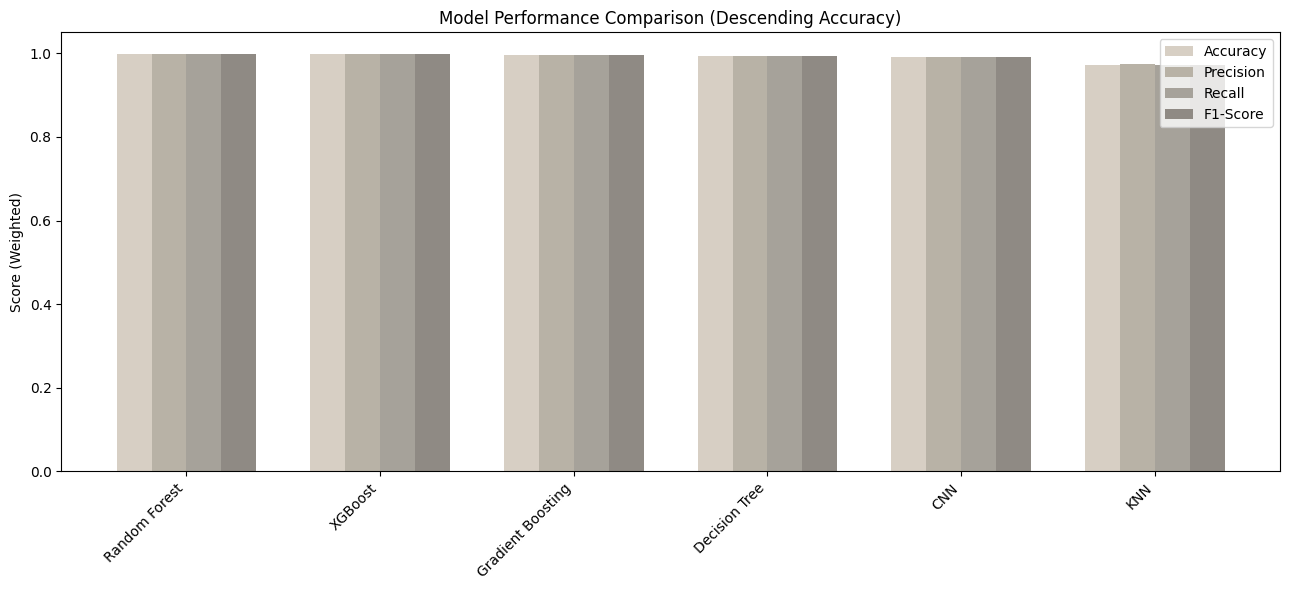

In [24]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------
# INPUT CSV (from comparison script)
# ---------------------------------
csv_path = "model_comparison_all_models.csv"

if not os.path.exists(csv_path):
    raise FileNotFoundError(f"CSV not found: {csv_path}")

# Load comparison results
df = pd.read_csv(csv_path, index_col=0)

# Metrics to visualize
metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]

# Replace NaN with 0 ONLY for visualization
plot_df = df[metrics].fillna(0)

# Number of models
n_models = len(plot_df)
indices = np.arange(n_models)

# Bar width
width = 0.18

# Beige–Grey undertone palette (same gradient style)
colors = [
    "#D7CFC4",  # Accuracy
    "#B8B2A6",  # Precision
    "#A6A29A",  # Recall
    "#8F8A84"   # F1-score
]

# Create figure
fig, ax = plt.subplots(figsize=(13, 6))

# Offsets for grouped bars
offsets = [-1.5*width, -0.5*width, 0.5*width, 1.5*width]

# Plot grouped bars
for metric, offset, color in zip(metrics, offsets, colors):
    ax.bar(
        indices + offset,
        plot_df[metric],
        width=width,
        label=metric,
        color=color
    )

# X-axis labels
ax.set_xticks(indices)
ax.set_xticklabels(plot_df.index.astype(str), rotation=45, ha="right")

# Axis labels and title
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score (Weighted)")
ax.set_title("Model Performance Comparison (Descending Accuracy)")

# Legend
ax.legend(loc="upper right")

# Layout adjustment
plt.tight_layout()

# ---------------------------------
# Save and display
# ---------------------------------
output_file = "grouped_model_comparison_all_models_beige_grey.png"
plt.savefig(output_file, dpi=200, bbox_inches="tight")

print(f"✅ Grouped bar chart saved as: {output_file}")

plt.show()


In [ ]:
import os

print(os.getcwd())
print(os.listdir())

c:\Users\labanya\Downloads\Geotunes
['.cache', 'app.py', 'audio.jpg', 'cnn_best_weights.keras', 'cnn_label_encoder.pkl', 'cnn_preprocessor.pkl', 'cnn_vibe_model.keras', 'cnn_vibe_model.pkl', 'Dockerfile', 'docs', 'inside_pages.png', 'knn_vibe_model.pkl', 'login_page.png', 'model_training.ipynb', 'README.md', 'requirements.txt', 'service_account.json', 'SONGS', 'tempCodeRunnerFile.ipynb', 'test_inputs', 'venv', 'vibe_dataset_balanced_7000.csv', 'vibe_knn_model.pkl', 'xgboost_training.ipynb', '__pycache__']


In [28]:
try:
    vibe_model = joblib.load("xgboost_vibe_model.pkl")
    encoder = joblib.load("vibe_label_encoder.pkl")

except Exception as e:
    print(f"Failed loading XGBoost model: {e}")